# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**: Kaggle - Heart Disease UCI (https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)

Dataset ini berisi informasi klinis pasien yang digunakan untuk memprediksi ada atau tidaknya penyakit jantung. Dataset ini sangat populer dan sering digunakan sebagai bencmark dalam klasifikasi biner.

2. **Informasi Dataset**:

*   **Jumlah Sampel**: 920 baris
*   **Jumlah Fitur**: 13 fitur + 1 target
*   **Task**: Binary Classification (0 = tidak ada penyakit jantung, 1 = ada penyakit jantung)

### Deskripsi Fitur:
| Fitur | Deskripsi | Tipe |
|-------|-----------|------|
| id  | ID Unik Pasien | Nominal |
| age | Usia pasien | Numerik |
| origin | Tempat belajar | Kategorikal |
| sex | Jenis kelamin (1=pria, 0=wanita) | Kategorikal |
| cp | Tipe nyeri dada (0-4) | Kategorikal |
| trestbps | Tekanan darah saat istirahat (mm Hg) | Numerik |
| chol | Kolesterol serum (mg/dl) | Numerik |
| fbs | Gula darah puasa > 120 mg/dl (1=benar, 0=salah) | Kategorikal |
| restecg | Hasil EKG saat istirahat (0-2) | Kategorikal |
| thalach | Detak jantung maksimum | Numerik |
| exang | Angina akibat olahraga (1=ya, 0=tidak) | Kategorikal |
| oldpeak | ST depression akibat olahraga | Numerik |
| slope | Kemiringan segmen ST (0-2) | Kategorikal |
| ca | Jumlah pembuluh darah utama (0-3) | Numerik |
| thal | Thalassemia (1=normal, 2=fixed defect, 3=reversable defect) | Kategorikal |
| num | Atribut yang diprediksi | Kategorical |

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Library berhasil diimport!')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

Library berhasil diimport!
Pandas version: 2.2.2
Numpy version: 2.0.2


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Dataset Heart Disease diambil langsung dari kaggle:
# https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
try:
  df = pd.read_csv('/content/sample_data/heart_disease_uci.csv')
  print('Dataset berhasil dimuat!')
except FileNotFoundError:
  print('Error: Dataset tidak ditemukan')
  # Membuat DataFrame kosong
  df = pd.DataFrame()
except Exception as e:
  print(f'Terjadi kesalahan saat memuat dataset: {e}')
  df = heart.frame

# Melanjutkan hanya jika DataFrame tidak kosong
if not df.empty:
    print('=== INFORMASI DATASET ===')
    print(f'Shape       : {df.shape}')
    print(f'Jumlah baris: {df.shape[0]}')
    print(f'Jumlah kolom: {df.shape[1]}')
    print()

    # Menampilkan beberapa baris awal dan akhir
    print('=== 5 BARIS PERTAMA ===')
    display(df.head())

    print('\n=== 5 BARIS TERAKHIR ===')
    display(df.tail())

    # Mengetahui tipe data
    print('\n=== TIPE DATA ===')
    print(df.dtypes)
else:
  print('Tidak dapat menampilkan informasi dataset karena gagal dimuat.')

Dataset berhasil dimuat!
=== INFORMASI DATASET ===
Shape       : (920, 16)
Jumlah baris: 920
Jumlah kolom: 16

=== 5 BARIS PERTAMA ===


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



=== 5 BARIS TERAKHIR ===


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1



=== TIPE DATA ===
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object


In [3]:
# Menyimpan dataset raw
df.to_csv('heart_raw.csv', index=False)
print('Dataset raw disimpan sebagai heart_raw.csv')
print(f'\nNama kolom: {list(df.columns)}')

Dataset raw disimpan sebagai heart_raw.csv

Nama kolom: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# 4.1 Statistik Deskriptif
print('=== STATISTIK DESKRIPTIF ===')
display(df.describe())

=== STATISTIK DESKRIPTIF ===


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
# 4.2 Cek Missing Values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== MISSING VALUES ===
          Missing Count  Missing %
id                    0   0.000000
age                   0   0.000000
sex                   0   0.000000
dataset               0   0.000000
cp                    0   0.000000
trestbps             59   6.413043
chol                 30   3.260870
fbs                  90   9.782609
restecg               2   0.217391
thalch               55   5.978261
exang                55   5.978261
oldpeak              62   6.739130
slope               309  33.586957
ca                  611  66.413043
thal                486  52.826087
num                   0   0.000000

Total missing values: 1759


In [6]:
# 4.3 Cek Data Duplikat
print('=== DATA DUPLIKAT ===')
duplicates = df.duplicated().sum()
print(f'Jumlah data duplikat: {duplicates}')
if duplicates > 0:
    print('Data duplikat ditemukan:')
    display(df[df.duplicated()])

=== DATA DUPLIKAT ===
Jumlah data duplikat: 0


=== DISTRIBUSI TARGET ===
Kolom 'num' berhasil dibinarisasi menjadi kolom 'target'.
target
0    411
1    509
Name: count, dtype: int64

Proporsi:
target
1    0.553
0    0.447
Name: proportion, dtype: float64


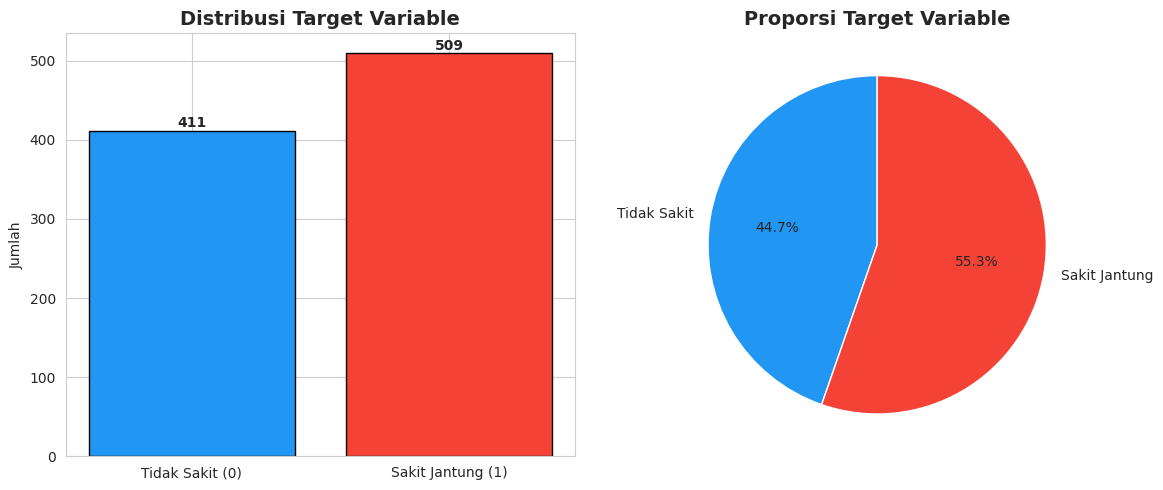

Plot disimpan sebagai eda_target_distribution.png


In [7]:
# 4.4 Distribusi Target Variable
# Kolom target pada dataset ini bernama 'num':
#  0           → tidak ada penyakit jantung
#  1, 2, 3, 4  → ada penyakit jantung
# Nilai > 0 dibinarisasi menjadi 1 untuk keperluan klasifikasi biner
print('=== DISTRIBUSI TARGET ===')

if 'num' not in df.columns:
    raise KeyError("Kolom 'num' tidak ditemukan. Periksa kembali file CSV.")

# Binarisasi: 0 = tidak sakit, 1 = sakit jantung
df['target'] = (df['num'] > 0).astype(int)
print("Kolom 'num' berhasil dibinarisasi menjadi kolom 'target'.")

# Menghitung frekuensi tiap kelas untuk visualisasi.
target_counts = df['target'].value_counts().sort_index()
print(target_counts)
print(f'\nProporsi:\n{df["target"].value_counts(normalize=True).round(3)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot — jumlah absolut tiap kelas.
axes[0].bar(['Tidak Sakit (0)', 'Sakit Jantung (1)'], target_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Distribusi Target Variable', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart — proporsi relatif antar kelas.
axes[1].pie(target_counts.values, labels=['Tidak Sakit', 'Sakit Jantung'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Proporsi Target Variable', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai eda_target_distribution.png')

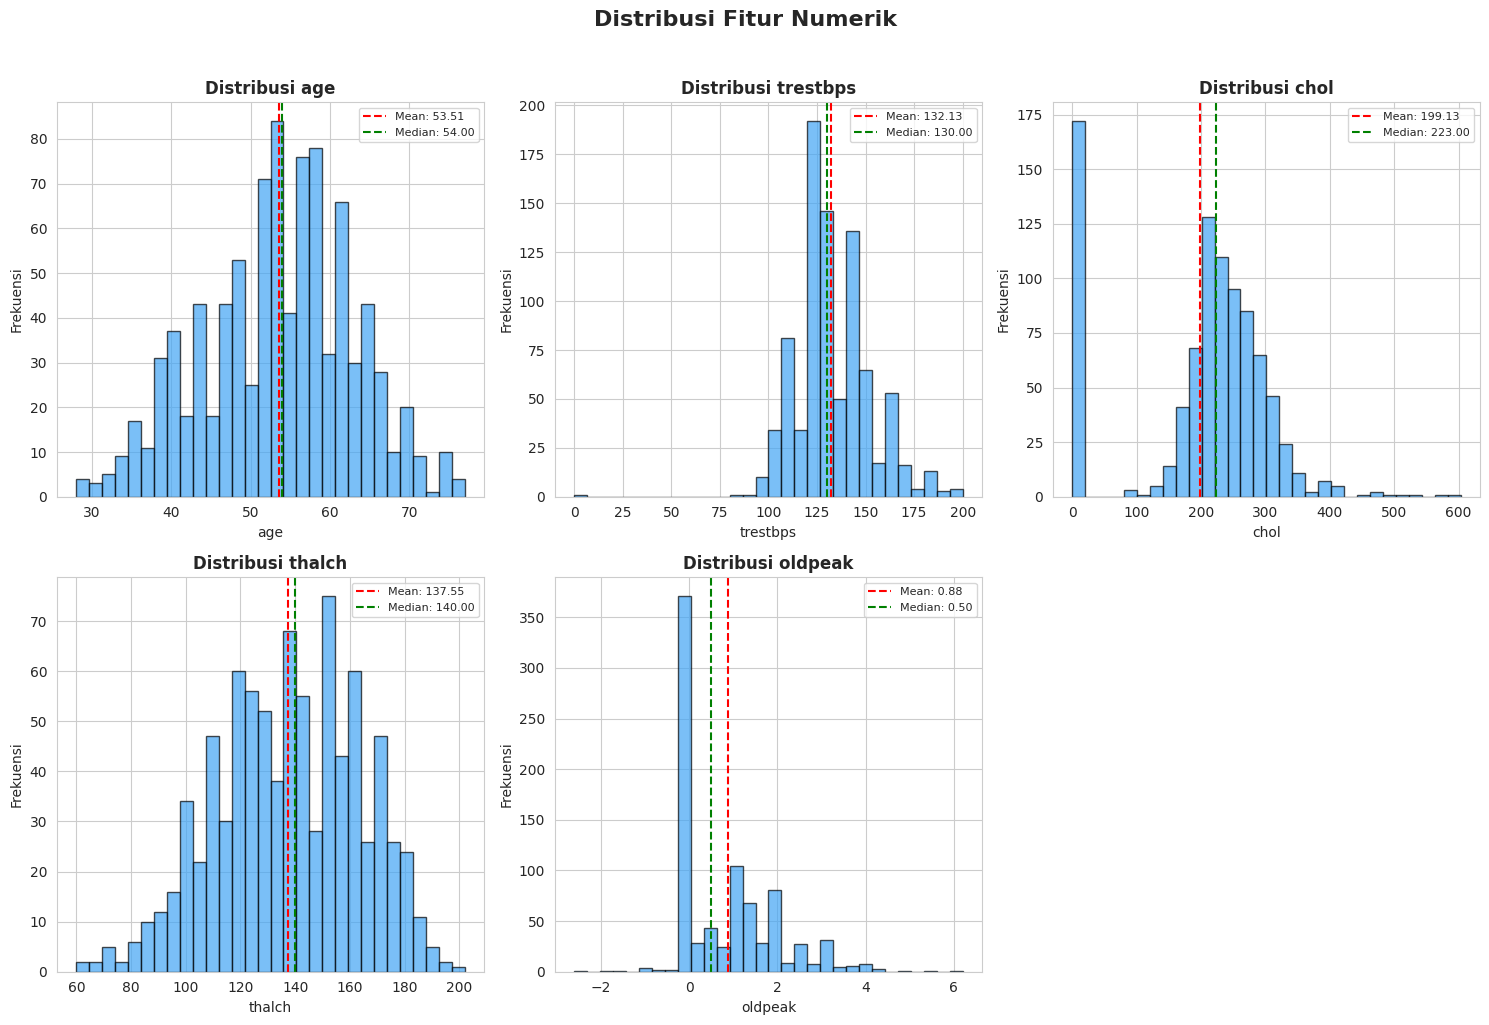

Plot disimpan sebagai eda_numerical_distribution.png


In [8]:
# 4.5 Distribusi Fitur Numerik
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# Grid 2x3 agar seluruh fitur dapat dibandingkan secara berdampingan.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, color='#42A5F5', edgecolor='black', alpha=0.7)
    # Garis merah = mean, garis hijau = median sebagai referensi distribusi
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[idx].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frekuensi')
    axes[idx].legend(fontsize=8)

# Slot keenam disembunyikan karena fitur hanya berjumlah 5.
axes[-1].axis('off')

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai eda_numerical_distribution.png')

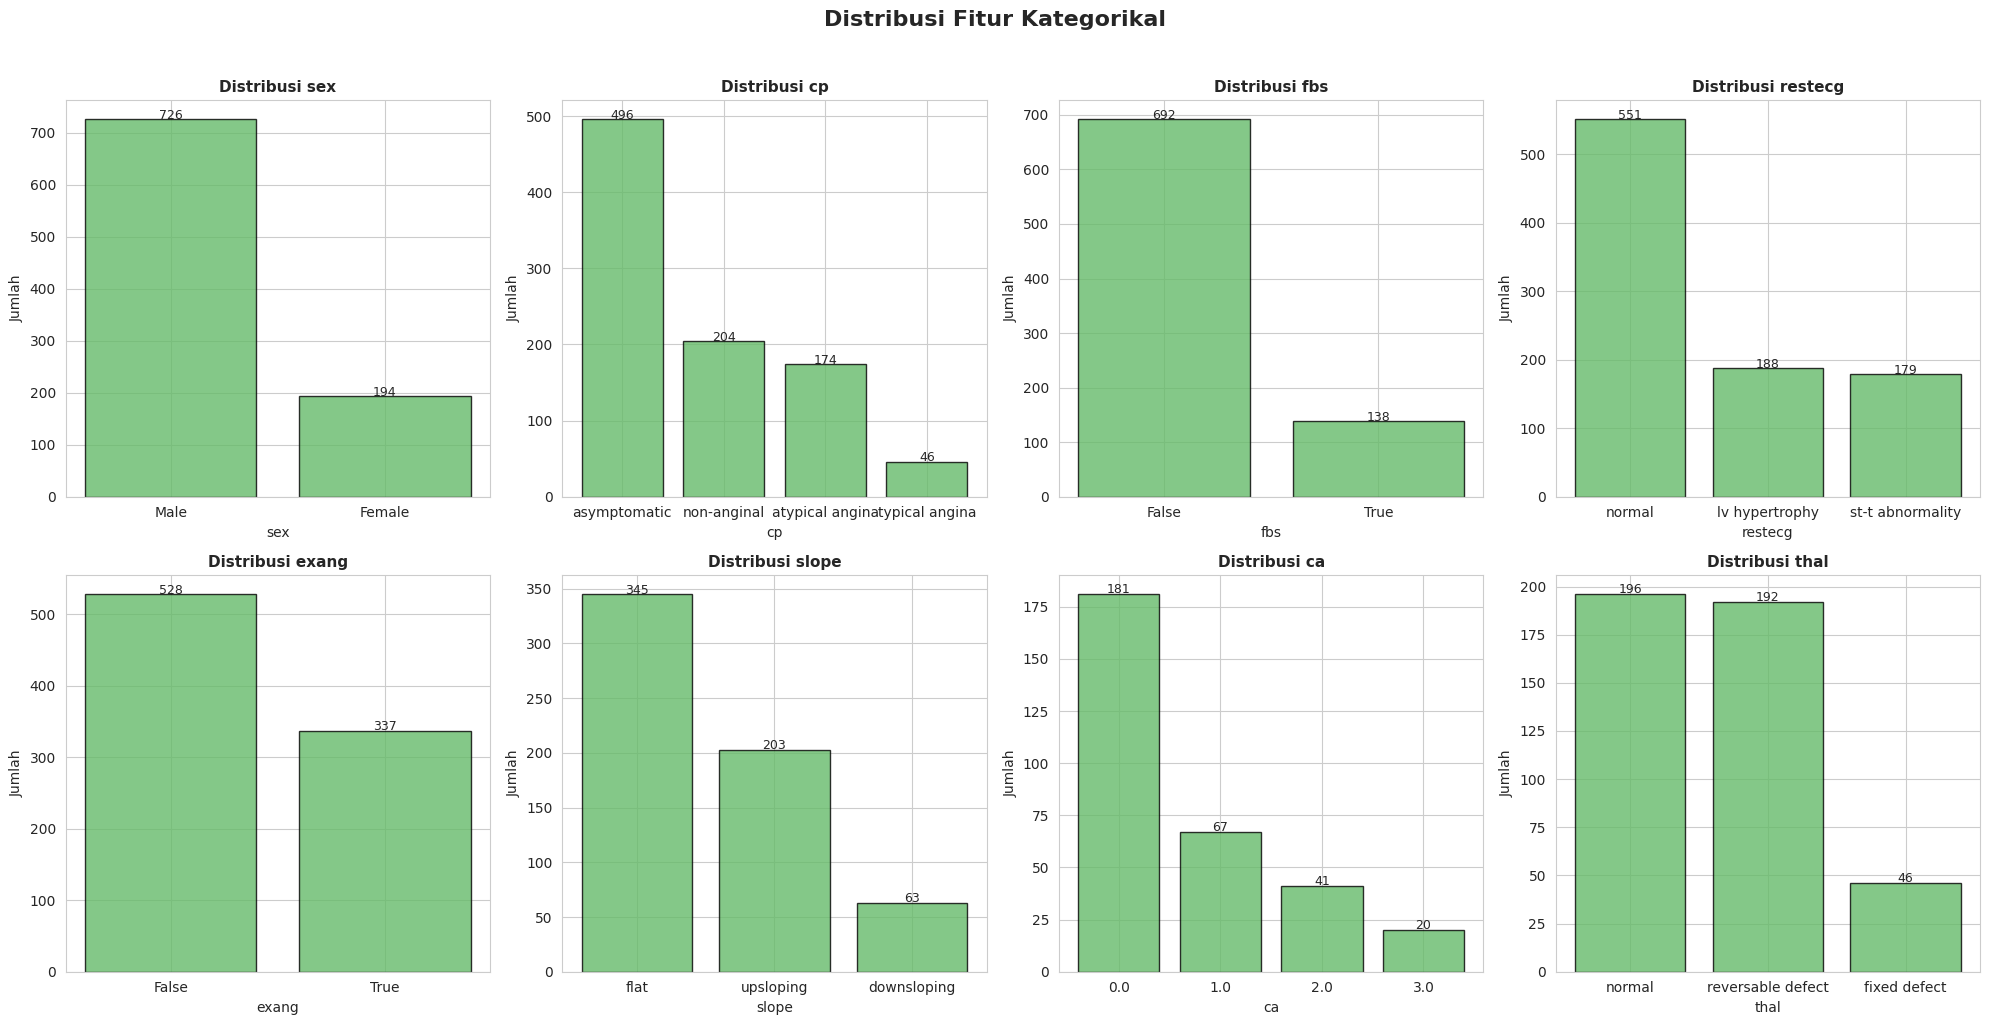

Plot disimpan sebagai eda_categorical_distribution.png


In [9]:
# 4.6 Distribusi Fitur Kategorikal
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Grid 2x4 menampung seluruh 8 fitur kategorikal sekaligus.
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Label frekuensi di atas setiap bar memudahkan pembacaan
for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[idx].bar(value_counts.index.astype(str), value_counts.values,
                  color='#66BB6A', edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Jumlah')
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_categorical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai eda_categorical_distribution.png')

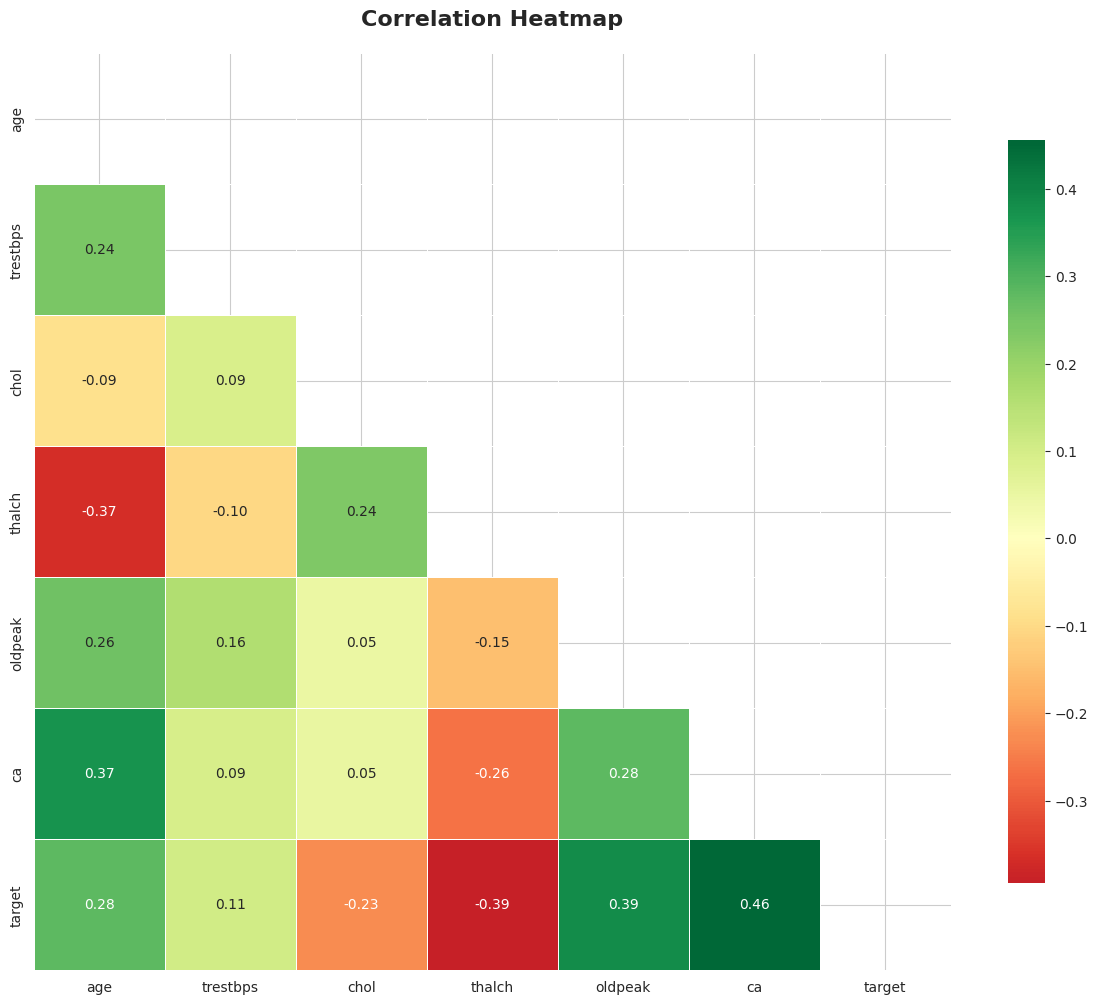

=== KORELASI DENGAN TARGET ===
target      1.000000
ca          0.455599
oldpeak     0.385528
age         0.282700
trestbps    0.106233
chol       -0.230583
thalch     -0.394503
Name: target, dtype: float64


In [10]:
# 4.7 Correlation Heatmap
# Hanya kolom numerik yang diikutsertakan
df_numeric = df.drop(columns=['num', 'id', 'dataset'], errors='ignore').select_dtypes(include='number')

plt.figure(figsize=(12, 10))
corr_matrix = df_numeric.corr()

# Segitiga atas disembunyikan agar heatmap tidak redundan
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            mask=mask,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Mengurutkan korelasi terhadap target dari tertinggi ke terendah
print('=== KORELASI DENGAN TARGET ===')
target_corr = corr_matrix['target'].sort_values(ascending=False)
print(target_corr)

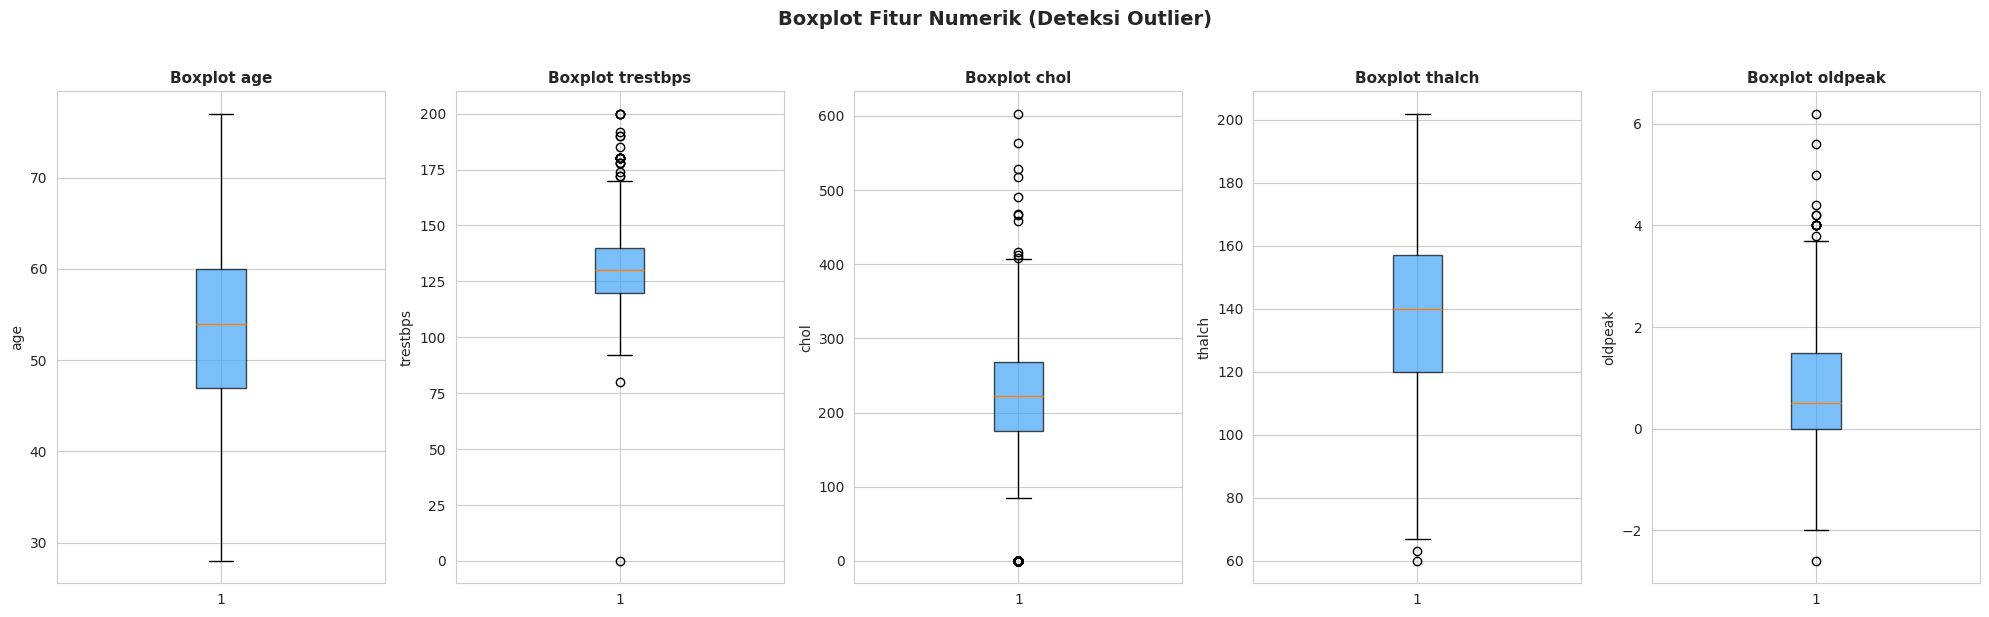

Plot disimpan sebagai eda_boxplot_outlier.png


In [11]:
# 4.8 Boxplot untuk Deteksi Outlier
# Setiap fitur ditampilkan dalam subplot terpisah
fig, axes = plt.subplots(1, 5, figsize=(20, 6))

for idx, col in enumerate(numerical_cols):
    # dropna() memastikan nilai kosong tidak mengganggu rendering boxplot.
    axes[idx].boxplot(df[col].dropna(), patch_artist=True,
                      boxprops=dict(facecolor='#42A5F5', alpha=0.7))
    axes[idx].set_title(f'Boxplot {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col)

plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai eda_boxplot_outlier.png')

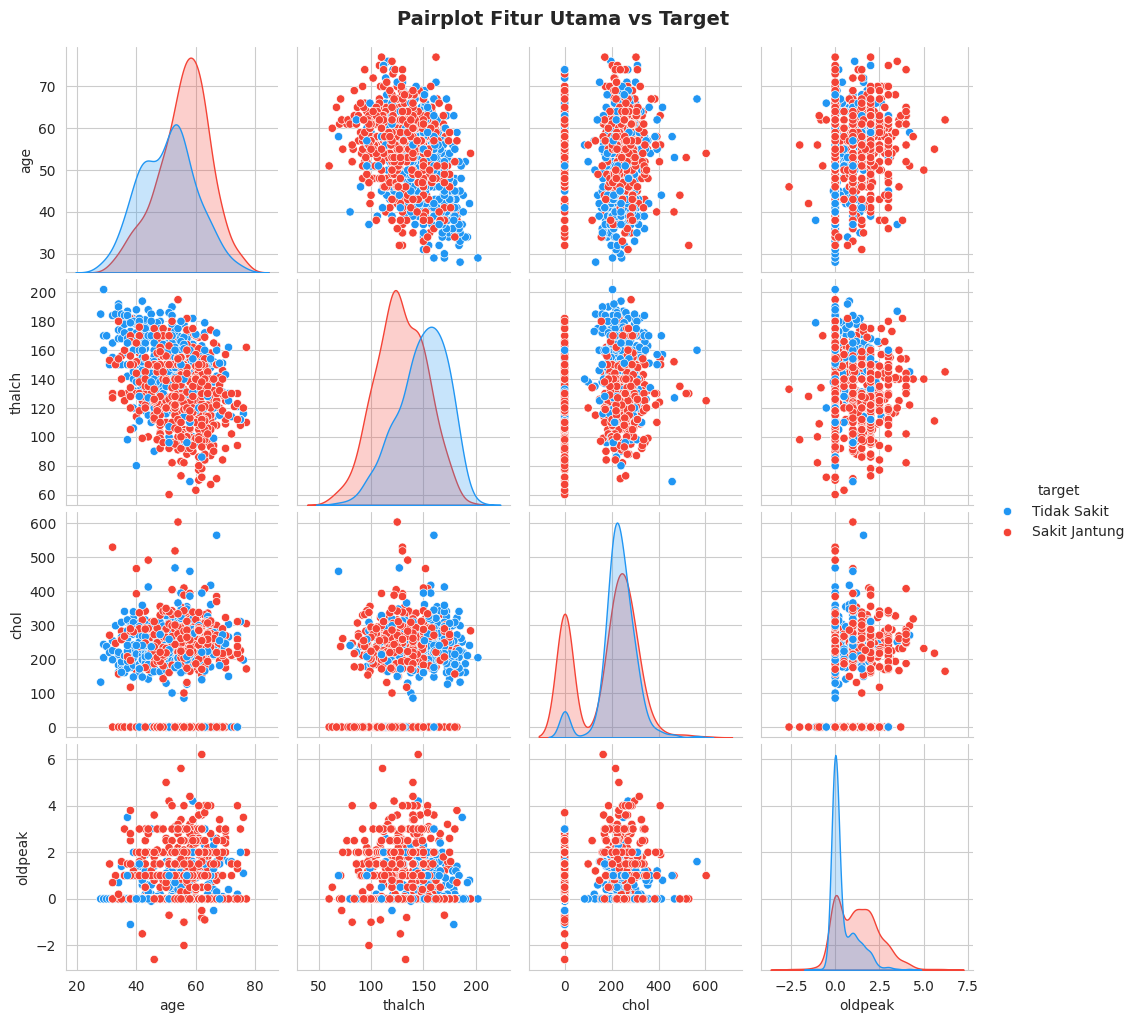

EDA selesai!


In [12]:
# 4.9 Pairplot Fitur Utama vs Target
# Melihat fitur yang mampu memisahkan kedua kelas
key_features = ['age', 'thalch', 'chol', 'oldpeak', 'target']

pair_df = df[key_features].copy()

# Label numerik diganti ke teks agar lebih mudah dibaca
pair_df['target'] = pair_df['target'].map({0: 'Tidak Sakit', 1: 'Sakit Jantung'})

# KDE dipilih untuk diagonal agar distribusi setiap fitur
sns.pairplot(pair_df, hue='target', diag_kind='kde',
             palette={'Tidak Sakit': '#2196F3', 'Sakit Jantung': '#F44336'})

plt.suptitle('Pairplot Fitur Utama vs Target', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('eda_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('EDA selesai!')

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# 5.1 Preprocessing — Persiapan Data
# Salinan dibuat agar dataset asli tetap bisa dirujuk kembali
df_clean = df.copy()
print(f'Shape awal: {df_clean.shape}')

# Step 1 - Hapus Data Duplikat
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f'\n[Step 1] Hapus Data Duplikat')
print(f'  Sebelum : {before} baris')
print(f'  Sesudah : {after} baris')
print(f'  Dihapus : {before - after} baris')

Shape awal: (920, 17)

[Step 1] Hapus Data Duplikat
  Sebelum : 920 baris
  Sesudah : 920 baris
  Dihapus : 0 baris


In [14]:
# STEP 2: Tangani Missing Values
print('[STEP 2] Tangani Missing Values')
print(f'  Missing values sebelum: {df_clean.isnull().sum().sum()}')

# Pisahkan fitur numerik dan kategorikal
numerical_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Imputasi numerik dengan median
num_imputer = SimpleImputer(strategy='median')
df_clean[numerical_features] = num_imputer.fit_transform(df_clean[numerical_features])

# Imputasi kategorikal dengan modus
cat_imputer = SimpleImputer(strategy='most_frequent')
df_clean[categorical_features] = cat_imputer.fit_transform(df_clean[categorical_features])

print(f'  Missing values sesudah: {df_clean.isnull().sum().sum()}')

[STEP 2] Tangani Missing Values
  Missing values sebelum: 1759
  Missing values sesudah: 0


In [15]:
# STEP 3: Deteksi dan Tangani Outlier (IQR)
print('[STEP 3] Deteksi dan Penanganan Outlier (IQR Method)')

def handle_outliers_iqr(df, columns):
    df_out = df.copy()
    outlier_info = {}
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers_count = ((df_out[col] < lower) | (df_out[col] > upper)).sum()
        # Clipping (Winsorization)
        df_out[col] = df_out[col].clip(lower=lower, upper=upper)
        outlier_info[col] = {
            'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
            'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2),
            'Outliers Clipped': outliers_count
        }
    return df_out, outlier_info

df_clean, outlier_report = handle_outliers_iqr(df_clean, numerical_features)
outlier_df = pd.DataFrame(outlier_report).T
print('\n  Laporan Outlier:')
display(outlier_df)

[STEP 3] Deteksi dan Penanganan Outlier (IQR Method)

  Laporan Outlier:


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Clipped
age,47.00,60.0,13.00,27.50,79.50,0.0
trestbps,120.00,140.0,20.00,90.00,170.00,28.0
chol,177.75,267.0,89.25,43.88,400.88,185.0
thalch,120.00,156.0,36.00,66.00,210.00,2.0
oldpeak,0.00,1.5,1.50,-2.25,3.75,16.0


In [16]:
# Step 4 — Encoding Data Kategorikal
# Fitur dengan >2 kategori → One-Hot Encoding
ohe_cols = ['cp', 'restecg', 'slope', 'thal']

# Fitur biner (sudah 0/1) → tidak perlu diencoding
binary_cols = ['sex', 'fbs', 'exang']

# Pastikan kolom OHE bertipe string sebelum get_dummies diterapkan
for col in ohe_cols:
    df_clean[col] = df_clean[col].astype(str)

df_encoded = pd.get_dummies(df_clean, columns=ohe_cols, prefix=ohe_cols, drop_first=False)

print(f'[Step 4] Encoding Data Kategorikal')
print(f'  Shape sebelum : {df_clean.shape}')
print(f'  Shape sesudah : {df_encoded.shape}')
print(f'  Kolom baru    : {[c for c in df_encoded.columns if c not in df_clean.columns]}')

[Step 4] Encoding Data Kategorikal
  Shape sebelum : (920, 17)
  Shape sesudah : (920, 26)
  Kolom baru    : ['cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect']


In [17]:
# Step 5 — Standarisasi Fitur Numerik
# Pisahkan fitur (x) dan target (y) sebelum scaling diterapkan.
X = df_encoded.drop(columns=['target'], errors='ignore')
y = df_encoded['target']

# Scaling hanya diterapkan pada kolom numerik
# kolom hasil One-Hot Encoding dibiarkan tetap biner.
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

print(f'[Step 5] Standarisasi Fitur Numerik')
print(f'  Fitur    : {numerical_features}')
print(f'  Shape X  : {X.shape}')
print(f'  Shape y  : {y.shape}')

# Nilai mean mendekati 0 dan std mendekati 1 menandakan scaling berhasil
print('\n  Statistik setelah standarisasi:')
display(X[numerical_features].describe().round(3))

[Step 5] Standarisasi Fitur Numerik
  Fitur    : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
  Shape X  : (920, 25)
  Shape y  : (920,)

  Statistik setelah standarisasi:


,age,trestbps,chol,thalch,oldpeak
count,920.000,920.000,920.000,920.000,920.000
mean,0.000,0.000,-0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001
min,-2.708,-2.467,-1.784,-2.856,-3.027
25%,-0.691,-0.693,-0.321,-0.705,-0.825
50%,0.052,-0.102,0.174,0.092,-0.336
75%,0.689,0.489,0.655,0.729,0.642
max,2.494,2.263,2.118,2.561,2.844


In [18]:
# Step 6 — Train-Test Split (80:20)
# Stratifikasi diterapkan agar proporsi kelas target terjaga sama di kedua subset.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'[Step 6] Train-Test Split (80:20, Stratified)')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  Distribusi y_train:\n{y_train.value_counts()}')
print(f'  Distribusi y_test :\n{y_test.value_counts()}')

[Step 6] Train-Test Split (80:20, Stratified)
  X_train : (736, 25)
  X_test  : (184, 25)
  Distribusi y_train:
target
1    407
0    329
Name: count, dtype: int64
  Distribusi y_test :
target
1    102
0     82
Name: count, dtype: int64


In [19]:
# Step 7 — Simpan Dataset Hasil Preprocessing
# Fitur dan target digabung kembali sebelum disimpan ke CSV.
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_csv('heart_preprocessing_train.csv', index=False)
test_df.to_csv('heart_preprocessing_test.csv', index=False)

print('[Step 7] Dataset Preprocessed Tersimpan')
print(f'  heart_preprocessing_train.csv : {train_df.shape}')
print(f'  heart_preprocessing_test.csv  : {test_df.shape}')
print('\n=== PREPROCESSING SELESAI ===')

[Step 7] Dataset Preprocessed Tersimpan
  heart_preprocessing_train.csv : (736, 26)
  heart_preprocessing_test.csv  : (184, 26)

=== PREPROCESSING SELESAI ===
